# Projekat: Analiza Sentimenta Steam Recenzija
## Tema: Primena Vestackih Neuronskih Mreza

**Dataset:** [Steam Reviews](https://www.kaggle.com/datasets/luthfim/steam-reviews-dataset)

**Cilj:** Predvidjanje sentimenta recenzije (pozitivno/negativno) na osnovu teksta.

**Biblioteke**: TensorFlow/Keras, scikit-learn, pandas, numpy

## Ucitavanje biblioteka i podataka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [61]:
df = pd.read_csv('data/steam_reviews.csv')

df.head()

,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title
0,2019-02-10,2,4,578,False,Recommended,&gt Played as German Reich&gt Declare war on B...,Expansion - Hearts of Iron IV: Man the Guns
1,2019-02-10,0,0,184,False,Recommended,yes.,Expansion - Hearts of Iron IV: Man the Guns
2,2019-02-07,0,0,892,False,Recommended,Very good game although a bit overpriced in my...,Expansion - Hearts of Iron IV: Man the Guns
3,2018-06-14,126,1086,676,False,Recommended,Out of all the reviews I wrote This one is pro...,Dead by Daylight
4,2017-06-20,85,2139,612,False,Recommended,Disclaimer I survivor main. I play games for f...,Dead by Daylight


## Deskriptivna analiza i priprema podataka

### Istrazivanje dataseta

In [62]:
print(f"Shape: {df.shape}")
print("\nNaziv kolona:")
print(df.columns.tolist())

print('\nInformacije o datasetu:')
print(df.info())
print('\nDistribucija sentimenta')
print(df['recommendation'].value_counts())
print('Statistike')
print(df.describe())

Shape: (434891, 8)

Naziv kolona:
['date_posted', 'funny', 'helpful', 'hour_played', 'is_early_access_review', 'recommendation', 'review', 'title']

Informacije o datasetu:
<class 'pandas.DataFrame'>
RangeIndex: 434891 entries, 0 to 434890
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   date_posted             434891 non-null  str  
 1   funny                   434891 non-null  int64
 2   helpful                 434891 non-null  int64
 3   hour_played             434891 non-null  int64
 4   is_early_access_review  434891 non-null  bool 
 5   recommendation          434891 non-null  str  
 6   review                  433375 non-null  str  
 7   title                   434891 non-null  str  
dtypes: bool(1), int64(3), str(4)
memory usage: 23.6 MB
None

Distribucija sentimenta
recommendation
Recommended        303593
Not Recommended    131298
Name: count, dtype: int64
Statistike
              funn

In [63]:
print('\nBroj nedostajucih vrednosti:\n')
print(df.isnull().sum())


Broj nedostajucih vrednosti:

date_posted                  0
funny                        0
helpful                      0
hour_played                  0
is_early_access_review       0
recommendation               0
review                    1516
title                        0
dtype: int64


### Data cleanup

In [64]:

df = df.copy()

In [65]:
missing_values = df['review'].isnull().sum()
print(f'Broj redova pre ciscenja: {len(df)}')
print(f"Nedostajuce vrednosti u 'review': {missing_values}")


df = df.dropna(subset=['review'])

df = df.reset_index(drop=True)


null_count = df['review'].isnull().sum()
print(f'\nBroj redova posle ciscenja: {len(df)}')
print(f'Nedostajuce vrednosti nakon ciscenja: {null_count}')
print(f'Uklonjeno redova: {missing_values}')

Broj redova pre ciscenja: 434891
Nedostajuce vrednosti u 'review': 1516

Broj redova posle ciscenja: 433375
Nedostajuce vrednosti nakon ciscenja: 0
Uklonjeno redova: 1516


### Distribucija Sentimenta

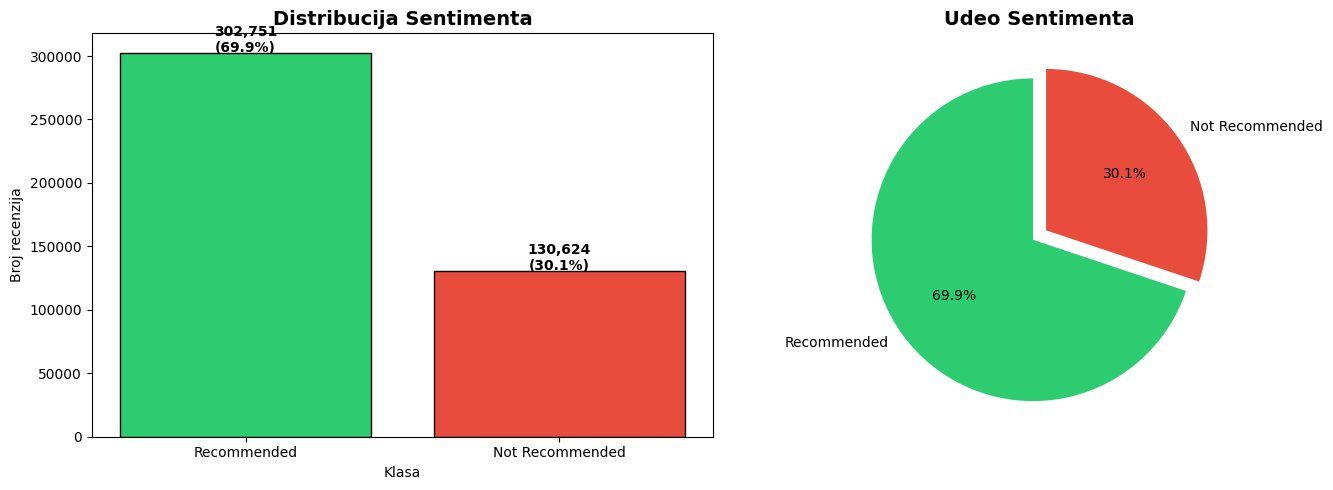

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = df['recommendation'].value_counts()

axes[0].bar(sentiment_counts.index, sentiment_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribucija Sentimenta', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Broj recenzija')

for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                 ha='center', fontweight='bold')

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Udeo Sentimenta', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

=== Statistike duzine recenzija ===
                    count   mean     std  min  25%   50%   75%     max
recommendation                                                        
Not Recommended  130624.0  54.63  101.96  1.0  7.0  22.0  59.0  2895.0
Recommended      302751.0  34.46   78.94  1.0  4.0  11.0  32.0  7984.0


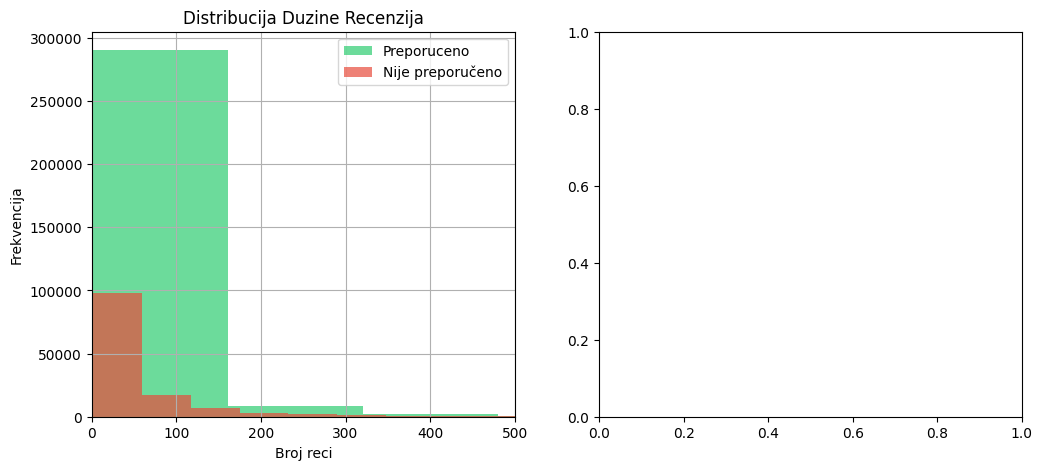

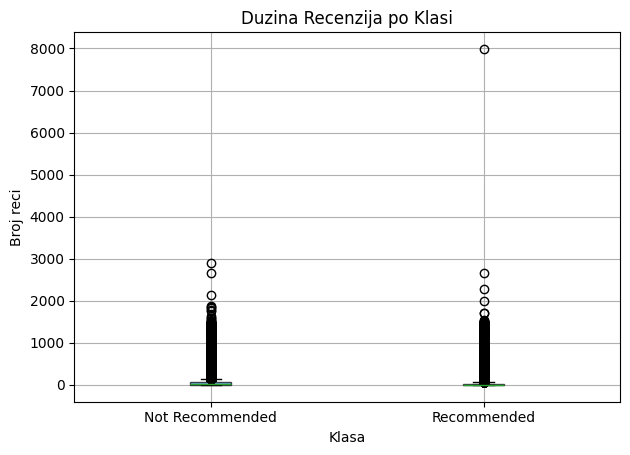

In [67]:
df['duzina_recenzije'] = df['review'].astype(str).apply(lambda x: len(x.split()))

print("=== Statistike duzine recenzija ===")
print(df.groupby('recommendation')['duzina_recenzije'].describe().round(2))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[df['recommendation'] == 'Recommended']['duzina_recenzije'].hist(
    bins=50, color='#2ecc71', alpha=0.7, label='Preporuceno')
df[df['recommendation'] == 'Not Recommended']['duzina_recenzije'].hist(
    bins=50, color='#e74c3c', alpha=0.7, label='Nije preporučeno')
plt.xlim(0, 500)
plt.title('Distribucija Duzine Recenzija')
plt.xlabel('Broj reci')
plt.ylabel('Frekvencija')
plt.legend()

plt.subplot(1, 2, 2)
df.boxplot(column='duzina_recenzije', by='recommendation', 
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7))
plt.title('Duzina Recenzija po Klasi')
plt.suptitle('')
plt.xlabel('Klasa')
plt.ylabel('Broj reci')

plt.tight_layout()
plt.show()

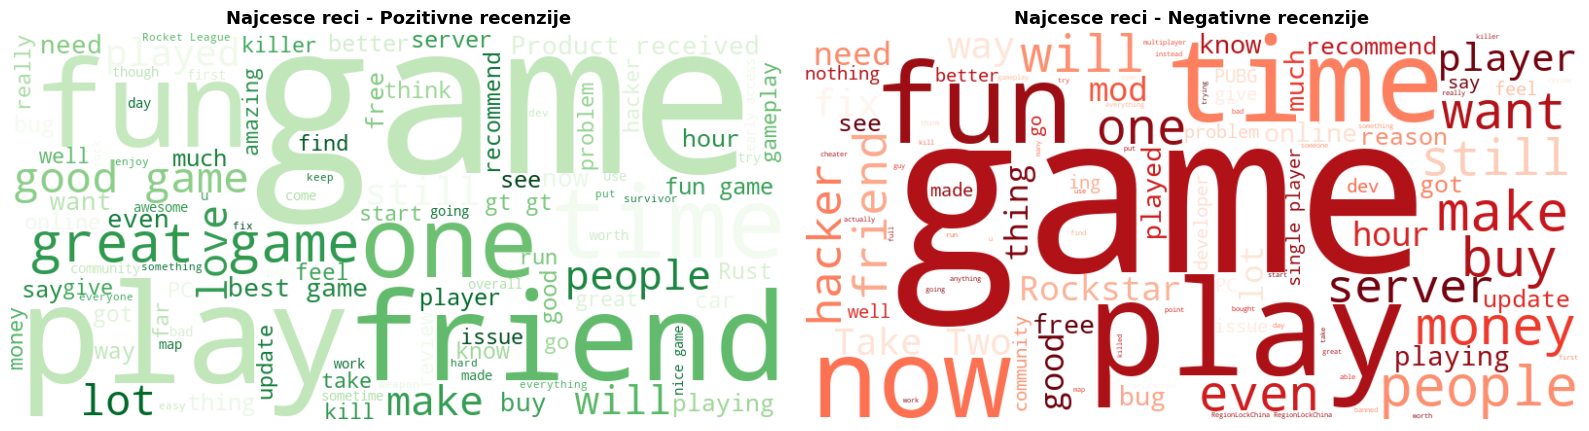

In [68]:
positive_text = ' '.join(
    df[df['recommendation'] == 'Recommended']['review'].astype(str).tolist()
)

negative_text = ' '.join(
    df[df['recommendation'] == 'Not Recommended']['review'].astype(str).tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Najcesce reci - Pozitivne recenzije', fontsize=13, fontweight='bold')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Najcesce reci - Negativne recenzije', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()